# Machine Learning Lab Evaluation

This lab includes two tasks: regression and classification. Each task compares three models: two traditional machine learning models and one neural network, with evaluations based on three metrics.

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np

In [3]:
import tensorflow as tf
devices = tf.config.list_physical_devices('GPU')

if devices:
    for device in devices:
        details = tf.config.experimental.get_device_details(device)
        print(f"TensorFlow GPU:0 -> {details['device_name']}")
else:
    print("ไม่พบ GPU")

ไม่พบ GPU


## Task 1: Regression

### Step 1: Load Dataset
We use the Boston Housing dataset for the regression task.

Use Numpy library to import dataset.
<br>`numpy.load(FILE_PATH, allow_pickle=True).item()`
<br>The dataset structure is dictionary-format.

In [4]:
# Load the data

# -------------------------------
FILE_PATH = 'boston-dataset.npy'
df = np.load(FILE_PATH, allow_pickle=True).item()
df
# Your code here
# -------------------------------

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

--- Data Shape ---
(506, 14)
--- Descriptive Statistics ---
                0           1           2           3           4           5  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

                6           7           8           9          10          11  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.2

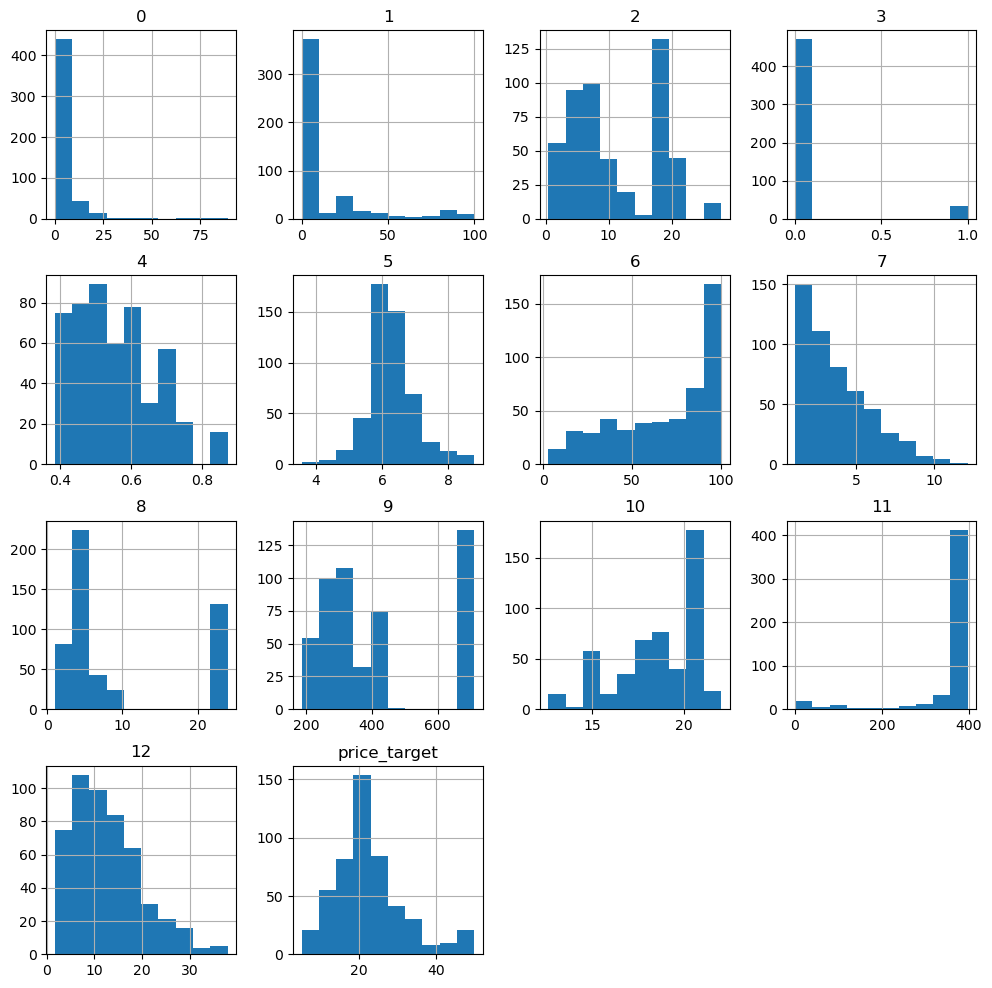

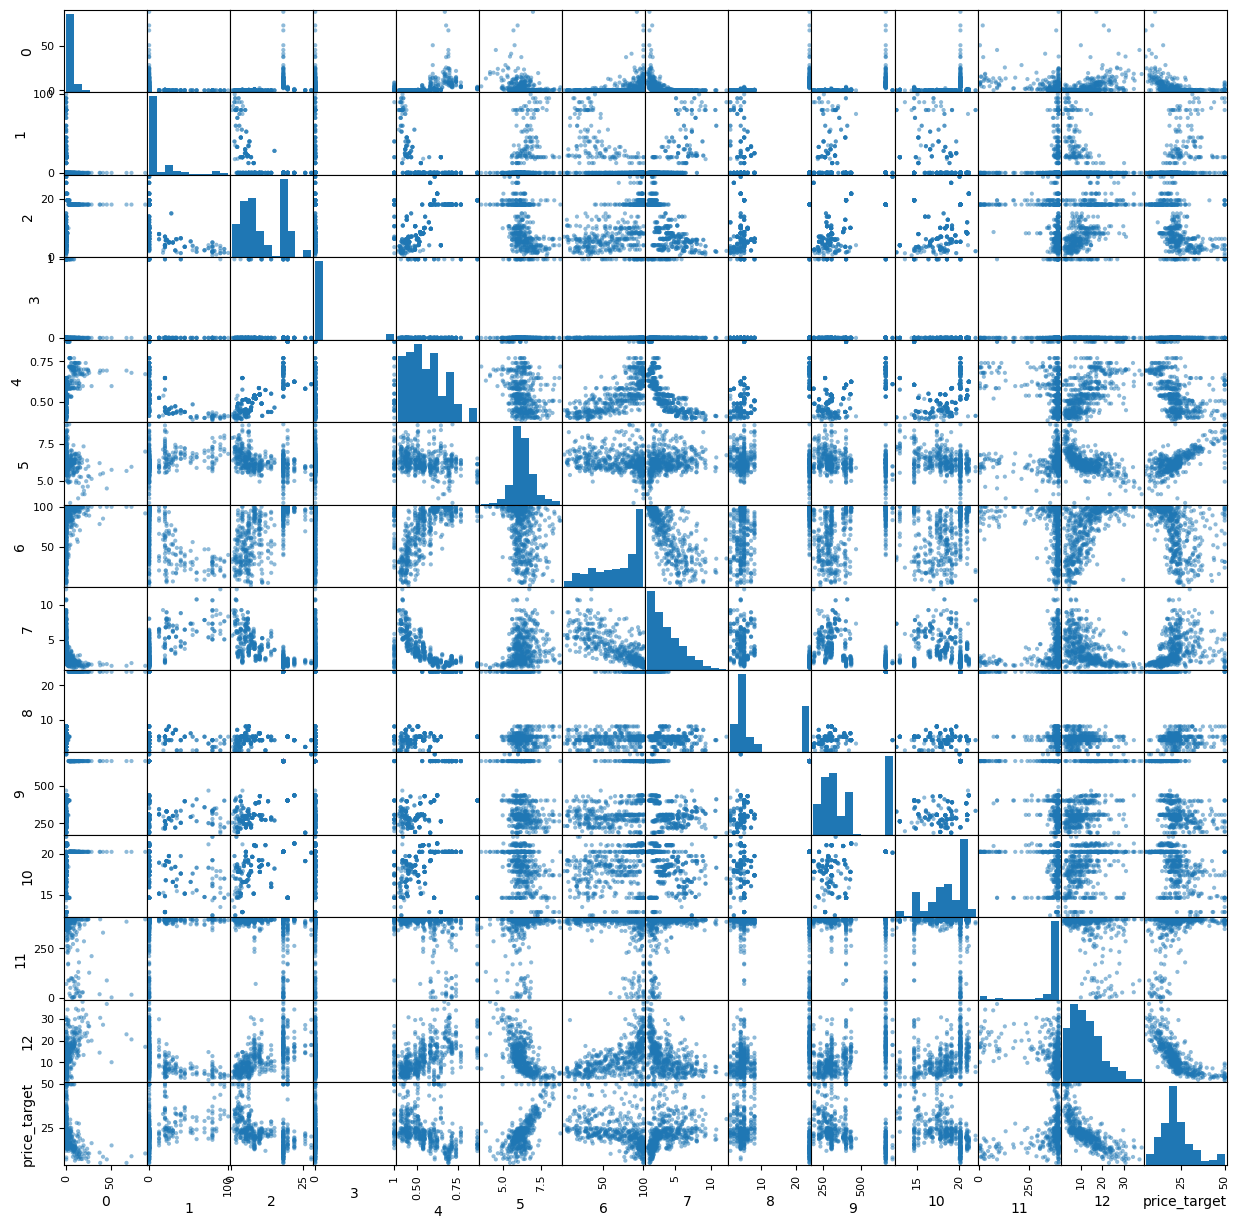

In [5]:
# --- สมมติว่าจบ Step 1 ที่โหลดข้อมูล df = np.load(...) เสร็จแล้ว ---

# 1. แปลงข้อมูล Numpy ให้เป็น Pandas DataFrame เพื่อทำ EDA
import pandas as pd
import matplotlib.pyplot as plt

# สร้าง DataFrame โดยเอา feature ('data') มารวมกับคำตอบ ('target')
boston_df = pd.DataFrame(df['data'])
boston_df['price_target'] = df['target']

# 2. เริ่มขั้นตอนทำ EDA (จาก Lab 2 และ Lab 3)
print("--- Data Shape ---")
print(boston_df.shape) # ดูจำนวนแถวและคอลัมน์ [3]

print("--- Descriptive Statistics ---")
print(boston_df.describe()) # ดูสถิติเบื้องต้น [5]

print("--- Correlation Matrix ---")
print(boston_df.corr()) # ดูว่าตัวแปรไหนสัมพันธ์กับราคา (price_target) มากที่สุด [8]

# 3. วาดกราฟ EDA
# วาดกราฟ Histogram เพื่อดูการกระจายตัวของข้อมูลแต่ละคอลัมน์ [7]
boston_df.hist(figsize=(12, 12)) 
plt.show()

# วาดกราฟ Scatter Matrix เพื่อดูความสัมพันธ์แบบจับคู่ [9]
pd.plotting.scatter_matrix(boston_df, figsize=(15, 15))
plt.show()

# --- หลังจากโค้ดส่วนนี้ ค่อยเข้าสู่ Step 2: Split and Scale Data ของ Lab 8 ต่อไป ---
# X = df['data']
# y = df['target']
# X_train, X_test, ... = train_test_split(...) 

In [6]:
# Show 3 samples of dataset

# -------------------------------
print('Feature')
print(df['data'][:3])
print()
print('Target')
print(df['target'][:3])
# Your code here
# -------------------------------

Feature
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]]

Target
[24.  21.6 34.7]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [7]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
X = df['data']
y = df['target']
# Random state is set to 42
df

# -------------------------------
# Your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# -------------------------------

# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data

# -------------------------------
# Your code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# -------------------------------

In [8]:
df

{'data': array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
         4.9800e+00],
        [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
         9.1400e+00],
        [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
         4.0300e+00],
        ...,
        [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         5.6400e+00],
        [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
         6.4800e+00],
        [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
         7.8800e+00]]),
 'target': array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
        18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
        15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
        13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
        21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
        35.4, 24.7, 3

In [9]:
# Show variable shape

# -------------------------------
print("X_train > >",X_train.shape)
print("y_train > >",y_train.shape)
print("X_test > > ",X_test.shape)
print("y_test > > ",y_test.shape)
# Your code here
# -------------------------------

X_train > > (404, 13)
y_train > > (404,)
X_test > >  (102, 13)
y_test > >  (102,)


### Step 3: Train Models
We train three models: Linear Regression, Random Forest Regressor, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [10]:
# Linear Regression
# Create a Linear Regression model
# -------------------------------
# Your code here
model = LinearRegression()
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
model.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred = model.predict(X_test)
# -------------------------------

In [11]:
# Random Forest Regressor
# Use RandomForestRegressor to train the model with random_state=42
# -------------------------------
# Your code here
rf_model = RandomForestRegressor(random_state=42)
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
rf_model.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_rf = rf_model.predict(X_test)
# -------------------------------

In [12]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function

nn_model_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model with adam optimizer and mean squared error loss function
# -------------------------------
# Your code here
nn_model_reg.compile(optimizer='adam', loss='mse')
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
# Your code here
history_reg = nn_model_reg.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))
# -------------------------------

# Predict the target values using the model
# -------------------------------
# Your code here
y_pred_nn = nn_model_reg.predict(X_test)
# -------------------------------

c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 546.5775 - val_loss: 406.7035
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 396.3689 - val_loss: 227.3821
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 195.5037 - val_loss: 73.1175
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 75.8659 - val_loss: 40.9112
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 40.7503 - val_loss: 29.9045
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 29.1396 - val_loss: 26.2175
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 24.9055 - val_loss: 23.7779
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 22.8417 - val_loss: 22.2694
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.2411 - val_loss: 20.7744
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19.7722 - val_loss: 19.5427
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.5523 - val_loss: 18.5900
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 

### Step 4: Evaluate Models
We evaluate the models using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score.

In [13]:
# Evaluate the models

# -------------------------------
# Your code here
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mse_nn = mean_squared_error(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Regression Task:")
print("Linear Regression:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")
print()
print("Random Forest Regressor:")
print(f"MSE: {mse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")
print()
print("Neural Network:")
print(f"MSE: {mse_nn:.4f}")
print(f"MAE: {mae_nn:.4f}")
print(f"R2 Score: {r2_nn:.4f}")
# -------------------------------

Regression Task:
Linear Regression:
MSE: 24.2911
MAE: 3.1891
R2 Score: 0.6688

Random Forest Regressor:
MSE: 7.9127
MAE: 2.0411
R2 Score: 0.8921

Neural Network:
MSE: 12.1385
MAE: 2.3382
R2 Score: 0.8345


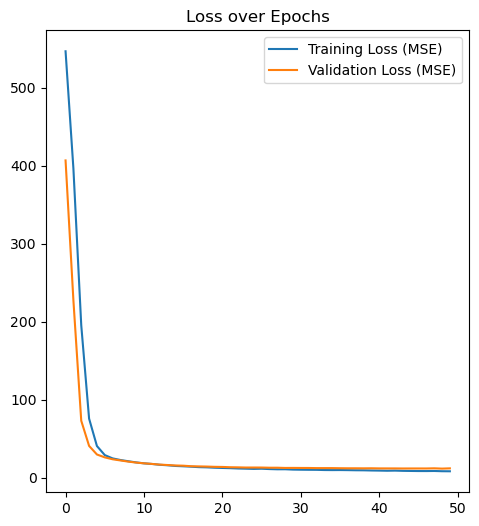

In [14]:
# 2. พล็อตกราฟ Loss (MSE) และ MAE (จาก Lab 6)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Training Loss (MSE)')
plt.plot(history_reg.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Loss over Epochs')
plt.legend()

plt.show()


---
---
---

## Task 2: Classification

### Step 1: Load Dataset
We use the Iris dataset for the classification task.

In [15]:
# Load the data
# -------------------------------
# Your code here 
CSV_PATH = 'student_dataset.csv'
df2 = pd.read_csv(CSV_PATH)
print(df2.info()) # ดูประเภทข้อมูล
print(df2.describe()) # ดูสถิติเบื้องต้น
print()
print(df2.isna().sum()) # นับจำนวนค่าว่าง (Missing Values) ในแต่ละคอลัมน์
df2["study_hours"].fillna(df2["study_hours"].mean(), inplace=True)
df2["attendance"].fillna(df2["attendance"].mean(), inplace=True)
# -------------------------------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df2['internet'] = le.fit_transform(df2['internet'])
df2['result'] = le.fit_transform(df2['result'])


# Show the first 5 rows of the dataset
# -------------------------------
# Your code here
df2.head()
# -------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          10 non-null     int64  
 1   study_hours  8 non-null      float64
 2   attendance   9 non-null      float64
 3   assignments  10 non-null     int64  
 4   internet     10 non-null     object 
 5   final_score  10 non-null     int64  
 6   result       10 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 692.0+ bytes
None
             age  study_hours  attendance  assignments  final_score
count  10.000000     8.000000    9.000000    10.000000     10.00000
mean   19.600000     2.875000   78.333333     6.700000     69.30000
std     1.429841     1.457738   15.644488     2.311805     22.78913
min    18.000000     1.000000   50.000000     3.000000     35.00000
25%    18.250000     1.750000   70.000000     5.250000     50.00000
50%    19.500000     3.000000   85.000000

C:\Users\Nebula\AppData\Local\Temp\ipykernel_14640\4104294724.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["study_hours"].fillna(df2["study_hours"].mean(), inplace=True)
C:\Users\Nebula\AppData\Local\Temp\ipykernel_14640\4104294724.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

,age,study_hours,attendance,assignments,internet,final_score,result
0,18,3.000,85.000000,8,1,78,2
1,19,1.000,60.000000,5,0,45,1
2,18,4.000,90.000000,9,1,92,0
3,20,2.875,70.000000,6,1,65,2
4,21,2.000,78.333333,4,0,40,1


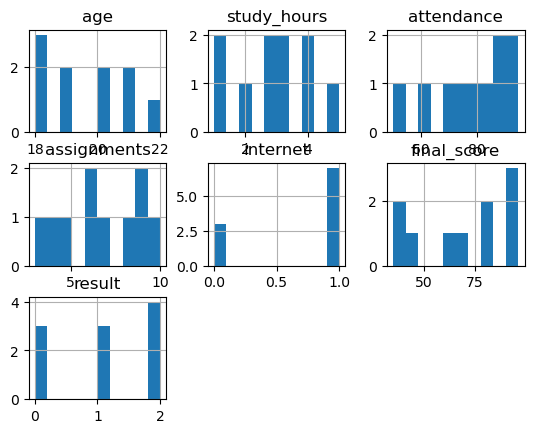

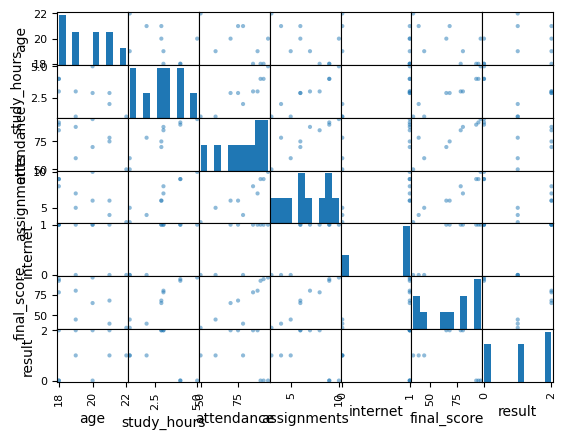

In [16]:
import matplotlib.pyplot as plt

# 1. ดูการกระจายตัวของข้อมูลแต่ละคอลัมน์
df2.hist()
plt.show()

# 2. ดูค่าสหสัมพันธ์ (Correlation Matrix) เพื่อหาตัวแปรที่ซ้ำซ้อน
df2.corr()

# 3. พล็อตกราฟ Scatter Matrix เพื่อดูความสัมพันธ์แบบคู่ (Pairwise)
pd.plotting.scatter_matrix(df2)
plt.show()

In [17]:
# Split the data into features and target

# -------------------------------
# Your code here
X = df2.drop('result', axis=1)
y = df2['result']

# -------------------------------

In [18]:
# Show 3 samples of features
# -------------------------------
# Your code here
print("Features")
print(X.values[:3])
print()
print("result")
print(y.values[:3])
# -------------------------------

Features
[[18.  3. 85.  8.  1. 78.]
 [19.  1. 60.  5.  0. 45.]
 [18.  4. 90.  9.  1. 92.]]

result
[2 1 0]


### Step 2: Split and Scale Data
We split the dataset into training and testing sets, then standardize the features for better performance.

In [19]:
# Split the data using train_test_split function
# 80% of the data will be used for training and 20% for testing
# Random state is set to 42
# -------------------------------
# Your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------

# Standardize the data
# Use StandardScaler to standardize the data
# Use fit_transform method on the training data and transform method on the testing data
# -------------------------------
# Your code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------

c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


### Step 2.5: Encode Target Variable
We encode the target variable using One-Hot Encoding.

In [20]:
# One-hot encode for neural network
# -------------------------------
# Your code here
y_train = to_categorical(y_train)
y_test = to_categorical(y_test, num_classes=3)
# -------------------------------

In [21]:
# Show variable shape
# -------------------------------
# Your code here
print("Variable shape")
print("X_train >> ", X_train.shape)
print("y_train >> ", y_train.shape)
print("X_test >> ", X_test.shape)
print("y_test >> ", y_test.shape)
# -------------------------------

Variable shape
X_train >>  (8, 6)
y_train >>  (8, 3)
X_test >>  (2, 6)
y_test >>  (2, 3)


### Step 3: Train Models
We train three models: Logistic Regression, Random Forest Classifier, and a Neural Network.
<br>Steps: 
1) Import/Build the model, 
2) Fit the model, 
3) Predict the target values.

In [22]:
# Logistic Regression
# Create a Logistic Regression model
# -------------------------------
# Your code here
lr_model = LogisticRegression()
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
lr_model.fit(X_train, np.argmax(y_train, axis=1))
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_lr = lr_model.predict(X_test)
# -------------------------------

In [23]:
# Random Forest Classifier
# Use RandomForestClassifier to train the model with random_state=42
# -------------------------------
# Your code here
rf_model_clf = RandomForestClassifier(random_state=42)
# -------------------------------

# Fit the model
# -------------------------------
# Your code here
rf_model_clf.fit(X_train, y_train)
# -------------------------------

# Predict the target values
# -------------------------------
# Your code here
y_pred_rf_clf = rf_model_clf.predict(X_test)
# -------------------------------

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# สมมติว่าสร้างโมเดล Random Forest ไว้แล้ว (rf_model_clf = RandomForestClassifier(...))
# 1. สร้างตัวแบ่งกลุ่มข้อมูลแบบ 5-Folds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. ทำการประเมินแบบ Cross-Validation ใน Training set
scores = cross_val_score(rf_model_clf, X_train, np.argmax(y_train, axis=1), cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {scores}")
print(f"Mean CV Accuracy: {scores.mean():.4f}")

c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Cross-Validation Accuracy Scores: [1.         0.66666667 1.        ]
Mean CV Accuracy: 0.8889


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# สร้างและ Train โมเดลเพิ่มเติม
svc_model = SVC(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

svc_model.fit(X_train, np.argmax(y_train, axis=1))
knn_model.fit(X_train, np.argmax(y_train, axis=1))
dt_model.fit(X_train, np.argmax(y_train, axis=1))

DecisionTreeClassifier(max_depth=3, random_state=42)

Epoch 1/50


c:\Users\Nebula\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2500 - loss: 1.4473 - val_accuracy: 0.5000 - val_loss: 8.2079
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7500 - loss: 1.0528 - val_accuracy: 0.5000 - val_loss: 7.4906
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.1250 - loss: 1.3193 - val_accuracy: 0.5000 - val_loss: 6.5498
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.2500 - loss: 1.3209 - val_accuracy: 0.5000 - val_loss: 5.4949
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.2500 - loss: 1.2058 - val_accuracy: 0.5000 - val_loss: 4.3822
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3750 - loss: 1.0692 - val_accuracy: 0.5000 - val_loss: 3.4877
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.3750 - loss: 1.1766 - val_accuracy: 0.5000 - val_loss: 2.5838
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5000 - loss: 1.0188 - val_accuracy: 0.5000 - val_loss: 1.6827
Epoch 

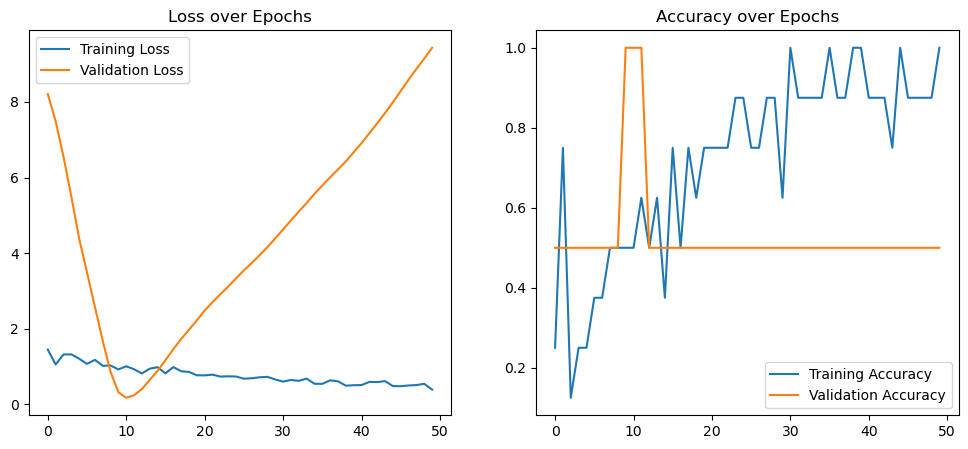

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


In [26]:
# Neural Network
# Create a neural network model with 2 hidden layers with 64 units and ReLU activation function
from tensorflow.keras.layers import Dense, Dropout

# โครงสร้างอ้างอิงตาม Lab 8 คือมี 2 Hidden layers (ชั้นละ 64)
nn_model_cls = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # ใช้ [1] เหมือนเดิม
    Dropout(0.3), # <--- แทรก Dropout เพื่อป้องกันโมเดลจำข้อสอบ (Overfitting)
    
    Dense(64, activation='relu'), # ชั้นซ่อน (Hidden Layer) ที่ 2
    Dropout(0.3), # <--- ใส่เพิ่มอีกชั้นได้เพื่อประสิทธิภาพที่ดีขึ้น
    
    Dense(y_train.shape[1], activation='softmax') # ใช้ [1] เหมือนเดิม
])

# Compile the model with adam optimizer and categorical crossentropy loss function
# Use accuracy as the metric
# -------------------------------
# Your code here
nn_model_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# -------------------------------

# Fit the model with 50 epochs and batch size of 16
# -------------------------------
# Your code here
# 1. ให้เพิ่มตัวแปร history มารับค่าการ fit
history = nn_model_cls.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# 2. พล็อตกราฟ Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

# 3. พล็อตกราฟ Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()
# -------------------------------

# Predict the target values using the model
# Use argmax to get the predicted class
# -------------------------------
# Your code here
y_pred_nn = nn_model_cls.predict(X_test)
y_pred_nn = np.argmax(y_pred_nn, axis=1)
# -------------------------------

In [27]:
X_train.shape

(8, 6)

### Step 4: Evaluate Models
We evaluate the models using Accuracy, Precision, and Recall.

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
# Evaluate the models
# -------------------------------
# Your code here
y_test_1d = np.argmax(y_test, axis=1)
y_pred_rf_1d = np.argmax(y_pred_rf_clf, axis=1)

print("Classification Task:")
print("Logistic Regression:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_lr):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_lr, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_lr))
print()
print("Random Forest Classifier:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_rf_1d):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_rf_1d, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_rf_1d))
print()
print("Neural Network:")
print("Accuracy:", f"{accuracy_score(y_test_1d, y_pred_nn):.4f}")
print("Precision:", f"{precision_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print("Recall:", f"{recall_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print("F1 Score:", f"{f1_score(y_test_1d, y_pred_nn, average='weighted'):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_nn))

# -------------------------------

Classification Task:
Logistic Regression:
Accuracy: 0.5000
Precision: 0.2500
Recall: 0.5000
F1 Score: 0.3333

Confusion Matrix:
[[1 0]
 [1 0]]

Random Forest Classifier:
Accuracy: 0.5000
Precision: 0.2500
Recall: 0.5000
F1 Score: 0.3333

Confusion Matrix:
[[1 0]
 [1 0]]

Neural Network:
Accuracy: 0.5000
Precision: 0.2500
Recall: 0.5000
F1 Score: 0.3333

Confusion Matrix:
[[1 0]
 [1 0]]


c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
y_pred_svc = svc_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# (แปลง y_test กลับเป็นมิติเดียว หากในโค้ดยังไม่มีตัวแปรนี้)
# y_test_1d = np.argmax(y_test, axis=1) 

# 2. ขั้นตอน Evaluate: แสดงผลลัพธ์ด้วย Confusion Matrix และ Classification Report
print("=== Support Vector Classifier (SVC) Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_svc))
print("Report:")
print(classification_report(y_test_1d, y_pred_svc, digits=4))
print("-" * 50)

print("=== k-Nearest Neighbors (k-NN) Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_knn))
print("Report:")
print(classification_report(y_test_1d, y_pred_knn, digits=4))
print("-" * 50)

print("=== Decision Tree Report ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_1d, y_pred_dt))
print("Report:")
print(classification_report(y_test_1d, y_pred_dt, digits=4))
print("-" * 50)

=== Support Vector Classifier (SVC) Report ===
Confusion Matrix:
[[0 0 1]
 [0 0 1]
 [0 0 0]]
Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       1.0
           1     0.0000    0.0000    0.0000       1.0
           2     0.0000    0.0000    0.0000       0.0

    accuracy                         0.0000       2.0
   macro avg     0.0000    0.0000    0.0000       2.0
weighted avg     0.0000    0.0000    0.0000       2.0

--------------------------------------------------
=== k-Nearest Neighbors (k-NN) Report ===
Confusion Matrix:
[[0 0 1]
 [0 0 1]
 [0 0 0]]
Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       1.0
           1     0.0000    0.0000    0.0000       1.0
           2     0.0000    0.0000    0.0000       0.0

    accuracy                         0.0000       2.0
   macro avg     0.0000    0.0000    0.0000       2.0
weighted avg     0.0000    0.0000    0.0000  

c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\s

In [30]:
print(classification_report(y_test_1d, y_pred_lr))
print(nn_model_cls.evaluate(X_test, y_test, verbose=2))
print(history.history['loss'])

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nebula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 - 0s - 78ms/step - accuracy: 0.5000 - loss: 9.4331
[9.433086395263672, 0.5]
[1.4473259449005127, 1.0528429746627808, 1.3193206787109375, 1.320905327796936, 1.2058300971984863, 1.0692293643951416, 1.1766020059585571, 1.0188274383544922, 1.027198314666748, 0.9233136177062988, 1.0069135427474976, 0.9274711608886719, 0.8169209957122803, 0.9430391788482666, 0.9818894863128662, 0.8179137706756592, 0.9851883053779602, 0.8753622174263, 0.8573028445243835, 0.7678418159484863, 0.7655357122421265, 0.78501296043396, 0.7341530323028564, 0.7405592203140259, 0.7357795834541321, 0.6769406795501709, 0.6894614696502686, 0.7145283222198486, 0.725789487361908, 0.6571450233459473, 0.6003626585006714, 0.6445246934890747, 0.6204738616943359, 0.6791876554489136, 0.5440881252288818, 0.5415868759155273, 0.63407301902771, 0.608323335647583, 0.4932660162448883, 0.504770815372467, 0.5086802244186401, 0.5932137370109558, 0.5886809825897217, 0.6136524677276611, 0.4827371835708618, 0.4788329005241394, 0.498636186

In [34]:
nn_model_cls.save('my_deeplearning_model.keras') 